In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from utils.Toolbox_detection import combined_value_counts, plot_sankley

In [3]:
def plot_grid(data, x_var, y_var, hue_var, col_var, row_var,
             col_order = None, row_order = None, ylims = None):
    # Define FacetGrid with tighter spacing
    g = sns.FacetGrid(
        data = data,
        col=col_var,
        row=row_var,
        col_order=data[col_var].sort_values().unique() if col_order is None else col_order,
        row_order=data[row_var].sort_values().unique() if row_order is None else row_order,
        margin_titles=True,  # Helps use space better
        despine=False,  # Keeps axes for reference
        height=1.75,  # Smaller subplot height
        aspect=1  # Adjust aspect ratio (width / height)
    )
    
    # Map barplot with narrower bars
    g.map_dataframe(
        sns.barplot,
        x=x_var,
        y=y_var,
        order=data[x_var].sort_values().unique(),
        hue=hue_var,
        hue_order=data[hue_var].sort_values().unique(),
        width=.8,
        palette='Dark2',
        zorder=10
    )
    
    # Reduce spacing between subplots
    g.fig.subplots_adjust(
        hspace=0.2,  # vertical space between rows
        wspace=0.05  # horizontal space between columns
    )
    
    # Reduce legend size and move to a compact position
    g.add_legend(title=hue_var)
    g._legend.set_bbox_to_anchor((1.25, 0.625))  # move legend to side
    g._legend.set_frame_on(False)

    ylims = (0, 100) if ylims is None else ylims
    # Optional: Rotate x-ticks and tighten layout
    for ax in g.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
            label.set_fontsize(8)
        # ax.set_ylabel('')
        # ax.set_xlabel('')
        ax.set_ylim(ylims)
        y_min, y_max = ax.get_ylim()
        ax.set_yticks(np.arange(y_min, y_max + 1, 10))
        ax.grid(zorder = 0)
    
    plt.tight_layout()
    plt.show()

In [143]:
# df_detect = pd.read_csv(f'results/density_base/traceback/NEW_WINDOW/compiled_detection.csv')
df_similarity = pd.read_csv(f'results/density_base/traceback/NEW_WINDOW/compiled_similarity.csv')
df_similarity.rename(columns = {'agg' : 'interval'}, inplace = True)

df_similarity.head()

,experiment,total_final_matches,total_warmup_matches,max_final_matches,max_warmup_matches,target_district_node,target_init_final_state,initial_state_mapping,exp_id,correct_epochs,correct_percent,window,step_size,interval,step_ratio,metric,ep_tag,detection
0,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WIND...,0,2,0,1,A_62,LL_LH,LL_HL_ML_LH_LL,12_3_43200__0,0.0,0.0,12,3,12,0.250,cosine,selected_epochs,0
1,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WIND...,0,5,0,1,A_62,LL_LH,LL_HL_ML_LH_LL,12_6_43200__0,0.0,0.0,12,6,12,0.500,cosine,selected_epochs,0
2,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WIND...,0,5,0,1,A_62,LL_LH,LL_HL_ML_LH_LL,12_9_43200__0,0.0,0.0,12,9,12,0.750,cosine,selected_epochs,0
3,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_3_NEW_WINDO...,0,10,0,2,A_62,LL_LH,LL_HL_ML_LH_LL,3_1_43200__0,0.0,0.0,3,1,12,0.333,cosine,selected_epochs,0
4,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_3_NEW_WINDO...,0,0,0,0,A_62,LL_LH,LL_HL_ML_LH_LL,3_2_43200__0,0.0,0.0,3,2,12,0.667,cosine,selected_epochs,0


In [208]:
df_similarity['target_district_node'] = df_similarity['target_district_node'].str[0]

df_similarity['init_state'] = df_similarity['target_init_final_state'].str[:2]
df_similarity['final_state'] = df_similarity['target_init_final_state'].str[-2:]

df_similarity[['A', 'B', 'C', 'D', 'E']] = df_similarity['initial_state_mapping'].str.split('_', expand=True)

df_similarity['detection'] = np.where(df_similarity['correct_percent'] >= 0.75, 1, 0)

def find_similar(row):
    match_cols = [col for col in ['A', 'B', 'C', 'D', 'E'] if row[col] == row['final_state']]
    return '_'.join(match_cols)


df_similarity['similar_districts'] = df_similarity.apply(find_similar, axis=1)

df_similarity.head()

,experiment,total_final_matches,total_warmup_matches,max_final_matches,max_warmup_matches,target_district_node,target_init_final_state,initial_state_mapping,exp_id,correct_epochs,...,ep_tag,detection,init_state,final_state,A,B,C,D,E,similar_districts
0,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WIND...,0,2,0,1,A,LL_LH,LL_HL_ML_LH_LL,12_3_43200__0,0.0,...,selected_epochs,0,LL,LH,LL,HL,ML,LH,LL,D
1,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WIND...,0,5,0,1,A,LL_LH,LL_HL_ML_LH_LL,12_6_43200__0,0.0,...,selected_epochs,0,LL,LH,LL,HL,ML,LH,LL,D
2,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_12_NEW_WIND...,0,5,0,1,A,LL_LH,LL_HL_ML_LH_LL,12_9_43200__0,0.0,...,selected_epochs,0,LL,LH,LL,HL,ML,LH,LL,D
3,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_3_NEW_WINDO...,0,10,0,2,A,LL_LH,LL_HL_ML_LH_LL,3_1_43200__0,0.0,...,selected_epochs,0,LL,LH,LL,HL,ML,LH,LL,D
4,A_62_LL_LH__LL_HL_ML_LH_LL_10_1_12_3_NEW_WINDO...,0,0,0,0,A,LL_LH,LL_HL_ML_LH_LL,3_2_43200__0,0.0,...,selected_epochs,0,LL,LH,LL,HL,ML,LH,LL,D


In [209]:
[
    'final_state', 'A', 'B', 'C', 'D', 'E', 'similar_districts' # geographical info
    'window', 'step_size', 'interval', 'step_ratio',            # time-series preprocessing
    'metric', 'ep_tag',                                         # processing variable
    'detection',                                                # target feature
]

['final_state',
 'A',
 'B',
 'C',
 'D',
 'E',
 'similar_districtswindow',
 'step_size',
 'interval',
 'step_ratio',
 'metric',
 'ep_tag',
 'detection']

In [210]:
processed_similar_P1 = df_similarity[(df_similarity['step_ratio'] == .444) | (df_similarity['step_ratio'] == .333) | (df_similarity['step_ratio'] == .667)].copy()

combined_value_counts(processed_similar_P1[['window', 'step_ratio', 'interval']], normalize=False, sort_index=True)

count   percent
window step_ratio interval                 
3      0.333      4           216  0.083333
                  6           216  0.083333
                  12          216  0.083333
       0.667      6           216  0.083333
                  12          216  0.083333
6      0.667      6           216  0.083333
                  12          216  0.083333
9      0.444      4           216  0.083333
                  6           216  0.083333
                  12          216  0.083333
       0.667      6           216  0.083333
                  12          216  0.083333

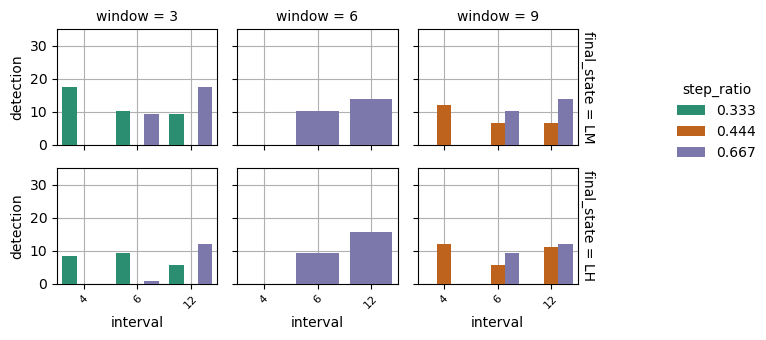

In [214]:
plot_similar_P1 = processed_similar_P1.groupby(['final_state', 'window', 'step_size', 'interval', 'step_ratio']).agg({
    'detection' : 'sum',
    'init_state' : 'count'
}).rename(columns = {'init_state' : 'count'}).reset_index()
plot_similar_P1['detection'] = 100*plot_similar_P1['detection'] / plot_similar_P1['count']

x_var = 'interval'
y_var = 'detection'
hue_var = 'step_ratio'

col_var = 'window'
row_var = 'final_state'

row_order = ['LM', 'LH']

plot_grid(data = plot_similar_P1, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (0,35))

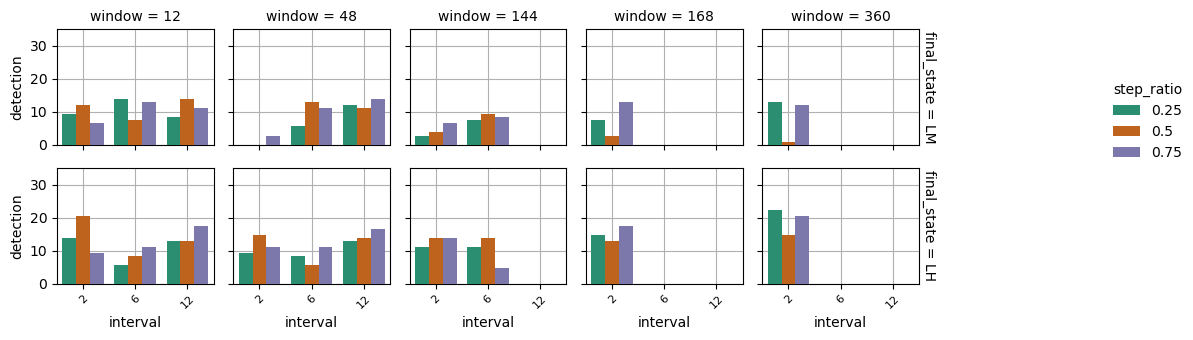

In [216]:
processed_similar_P2 = df_similarity[(df_similarity['step_ratio'] != .444) & (df_similarity['step_ratio'] != .333) & (df_similarity['step_ratio'] != .667)].copy()

processed_similar_P2 = processed_similar_P2[(processed_similar_P2['window'] != 6) & (processed_similar_P2['interval'] != 3) & (processed_similar_P2['window'] != 84)]

plot_similar_P2 = processed_similar_P2.groupby(['final_state', 'window', 'step_size', 'interval', 'step_ratio']).agg({
    'detection' : 'sum',
    'init_state' : 'count'
}).rename(columns = {'init_state' : 'count'}).reset_index()
plot_similar_P2['detection'] = 100*plot_similar_P2['detection'] / plot_similar_P2['count']

x_var = 'interval'
y_var = 'detection'
hue_var = 'step_ratio'

col_var = 'window'
row_var = 'final_state'

row_order = ['LM', 'LH']

plot_grid(data = plot_similar_P2, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (0,35))

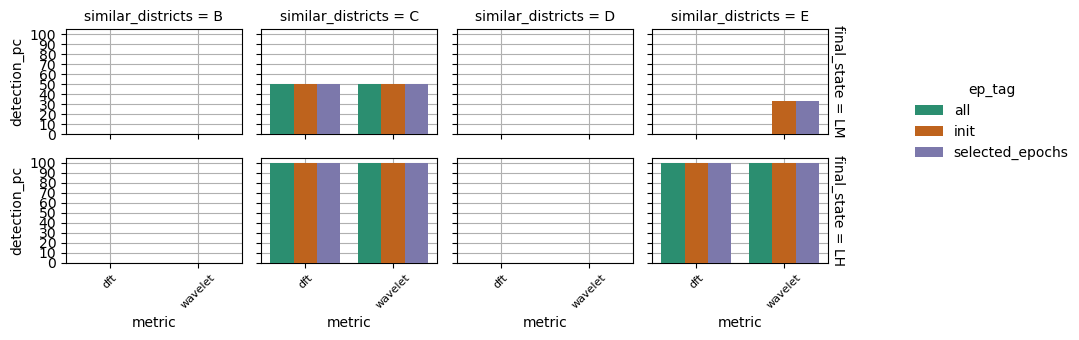

In [248]:
processed_similar_P2_selected = processed_similar_P2[(processed_similar_P2['window'] == 12) & (processed_similar_P2['interval'] == 12) & (processed_similar_P2['step_ratio'] == .75)]

processed_similar_P2_selected = processed_similar_P2_selected[(processed_similar_P2_selected['metric'].isin(['dft', 'wavelet']))  
                                                             # & (processed_similar_P2_selected['ep_tag'] == 'all')
                                                            # (processed_similar_P2_selected['skip_tgt'] == True)
    ]


plot_similar_P2_selected = processed_similar_P2_selected.groupby([
                                                                    'final_state', 'similar_districts', # geographical info
                                                                    'metric', 'ep_tag',                 # processing variable
                                                                ]
                                                              ).agg({
                                                                    'detection' : 'sum',
                                                                    'init_state' : 'count'
                                                                }).rename(columns = {'init_state' : 'count'}).reset_index()

plot_similar_P2_selected['detection_pc'] = 100*plot_similar_P2_selected['detection'] / plot_similar_P2_selected['count']


x_var = 'metric'
y_var = 'detection_pc'
hue_var = 'ep_tag'

col_var = 'similar_districts'
row_var = 'final_state'
row_order = ['LM', 'LH']

plot_grid(data = plot_similar_P2_selected, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (0,105))

In [250]:
qwe = plot_similar_P2_selected.copy()
qwe[(qwe['similar_districts'] == 'C') & (qwe['ep_tag'] == 'all') & (qwe['metric'] == 'wavelet')]

,final_state,similar_districts,metric,ep_tag,detection,count,detection_pc
9,LH,C,wavelet,all,2,2,100.0
33,LM,C,wavelet,all,1,2,50.0


In [6]:
import glob
import os
import pandas as pd

# Step 1: Get all matching directories
# base_path = 'results/income_base/traceback/HYPER_INCOME'
base_path = 'results/density_base/traceback/HYPER'
pattern = os.path.join(base_path, '*2_*/')
directories = [d for d in glob.glob(pattern) if os.path.isdir(d)]

# Step 2: Count files in each directory

aux_det = []
aux_sim = []

for dir_path in directories:
    files = [f for f in glob.glob(os.path.join(dir_path, '*')) if os.path.isfile(f)]
    sim = pd.read_csv(f'{dir_path}/compiled_similarity.csv')
    aux_sim.append(sim)

df_similar_hyper = pd.concat(aux_sim, ignore_index=True)
df_similar_hyper.rename(columns = {'agg' : 'interval', 'infonet' : 'info'}, inplace = True)


df_similar_hyper['target_district_node'] = df_similar_hyper['target_district_node'].str[0]

df_similar_hyper['init_state'] = df_similar_hyper['target_init_final_state'].str[:2]
df_similar_hyper['final_state'] = df_similar_hyper['target_init_final_state'].str[-2:]


df_similar_hyper[['A', 'B', 'C', 'D', 'E']] = df_similar_hyper['initial_state_mapping'].str.split('_', expand=True)
df_similar_hyper['detection'] = np.where(df_similar_hyper['correct_percent'] >= 0.75, 1, 0)

def find_similar(row):
    match_cols = [col for col in ['B', 'C', 'D', 'E'] if row[col] == row['final_state']]
    return '_'.join(match_cols)


df_similar_hyper['similar_districts'] = df_similar_hyper.apply(find_similar, axis=1)

df_similar_hyper.head()

,experiment,total_final_matches,total_warmup_matches,max_final_matches,max_warmup_matches,target_district_node,target_init_final_state,initial_state_mapping,exp_id,correct_epochs,...,ep_tag,detection,init_state,final_state,A,B,C,D,E,similar_districts
0,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_4_12_EXPERIMEN...,9,9,3,3,A,LL_LH,LL_LH_LL_LL_LM,12_2_14400_10_0.05__0,0.375000,...,init,0,LL,LH,LL,LH,LL,LL,LM,B
1,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_4_12_EXPERIMEN...,7,7,3,3,A,LL_LH,LL_LH_LL_LL_LM,12_2_14400_10_0.1__0,0.291667,...,init,0,LL,LH,LL,LH,LL,LL,LM,B
2,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_4_12_EXPERIMEN...,7,7,3,3,A,LL_LH,LL_LH_LL_LL_LM,12_2_14400_10_0.2__0,0.291667,...,init,0,LL,LH,LL,LH,LL,LL,LM,B
3,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_4_12_EXPERIMEN...,7,7,3,3,A,LL_LH,LL_LH_LL_LL_LM,12_2_14400_10_0.4__0,0.291667,...,init,0,LL,LH,LL,LH,LL,LL,LM,B
4,A_62_LL_LH__LL_LH_LM_LL_LL_10_1_4_12_EXPERIMEN...,0,12,0,4,A,LL_LH,LL_LH_LM_LL_LL,12_2_14400_10_0.05__0,0.000000,...,init,0,LL,LH,LL,LH,LM,LL,LL,B


In [8]:
processed_similar_hyper = df_similar_hyper.copy()

for c in ['window', 'step_size', 'interval', 'lstm']:
    processed_similar_hyper[c] = processed_similar_hyper[c].astype(int)
    

processed_similar_hyper['init_state'] = processed_similar_hyper['target_init_final_state'].str[:2]
processed_similar_hyper['final_state'] = processed_similar_hyper['target_init_final_state'].str[3:5]


def find_similar(row):
    match_cols = [col for col in ['A', 'B', 'C', 'D', 'E'] if row[col] == row['final_state']]
    return '_'.join(match_cols)


processed_similar_hyper['similar_districts'] = processed_similar_hyper.apply(find_similar, axis=1)


for c in ['window', 'step_size', 'interval', 'lstm', 'info']:
    print(c, processed_similar_hyper[c].unique().tolist())
    
processed_similar_hyper.head()

window [12]
step_size [2]
interval [4]
lstm [10, 30, 40, 60]
info [0.05, 0.1, 0.2, 0.4]


,experiment,total_final_matches,total_warmup_matches,max_final_matches,max_warmup_matches,target_district_node,target_init_final_state,initial_state_mapping,exp_id,correct_epochs,...,ep_tag,detection,init_state,final_state,A,B,C,D,E,similar_districts
0,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_4_12_EXPERIMEN...,9,9,3,3,A,LL_LH,LL_LH_LL_LL_LM,12_2_14400_10_0.05__0,0.375000,...,init,0,LL,LH,LL,LH,LL,LL,LM,B
1,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_4_12_EXPERIMEN...,7,7,3,3,A,LL_LH,LL_LH_LL_LL_LM,12_2_14400_10_0.1__0,0.291667,...,init,0,LL,LH,LL,LH,LL,LL,LM,B
2,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_4_12_EXPERIMEN...,7,7,3,3,A,LL_LH,LL_LH_LL_LL_LM,12_2_14400_10_0.2__0,0.291667,...,init,0,LL,LH,LL,LH,LL,LL,LM,B
3,A_62_LL_LH__LL_LH_LL_LL_LM_10_1_4_12_EXPERIMEN...,7,7,3,3,A,LL_LH,LL_LH_LL_LL_LM,12_2_14400_10_0.4__0,0.291667,...,init,0,LL,LH,LL,LH,LL,LL,LM,B
4,A_62_LL_LH__LL_LH_LM_LL_LL_10_1_4_12_EXPERIMEN...,0,12,0,4,A,LL_LH,LL_LH_LM_LL_LL,12_2_14400_10_0.05__0,0.000000,...,init,0,LL,LH,LL,LH,LM,LL,LL,B


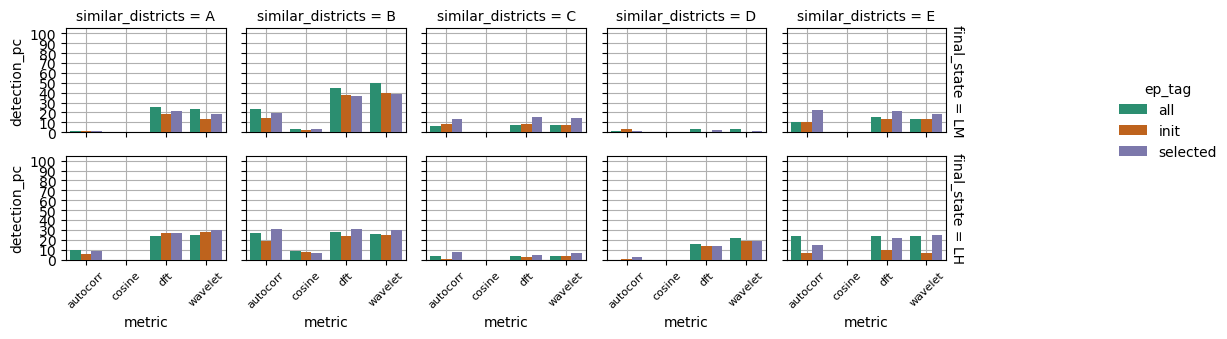

In [10]:
plot_similar_P2_hyper = processed_similar_hyper.groupby([
                                                                    'final_state', 'similar_districts', # geographical info
                                                                    'metric', 'ep_tag',                 # processing variable
                                                                ]
                                                              ).agg({
                                                                    'detection' : 'sum',
                                                                    'init_state' : 'count'
                                                                }).rename(columns = {'init_state' : 'count'}).reset_index()

plot_similar_P2_hyper['detection_pc'] = 100*plot_similar_P2_hyper['detection'] / plot_similar_P2_hyper['count']

x_var = 'metric'
y_var = 'detection_pc'
hue_var = 'ep_tag'

col_var = 'similar_districts'
row_var = 'final_state'
row_order = ['LM', 'LH']

plot_grid(data = plot_similar_P2_hyper, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (0,105))

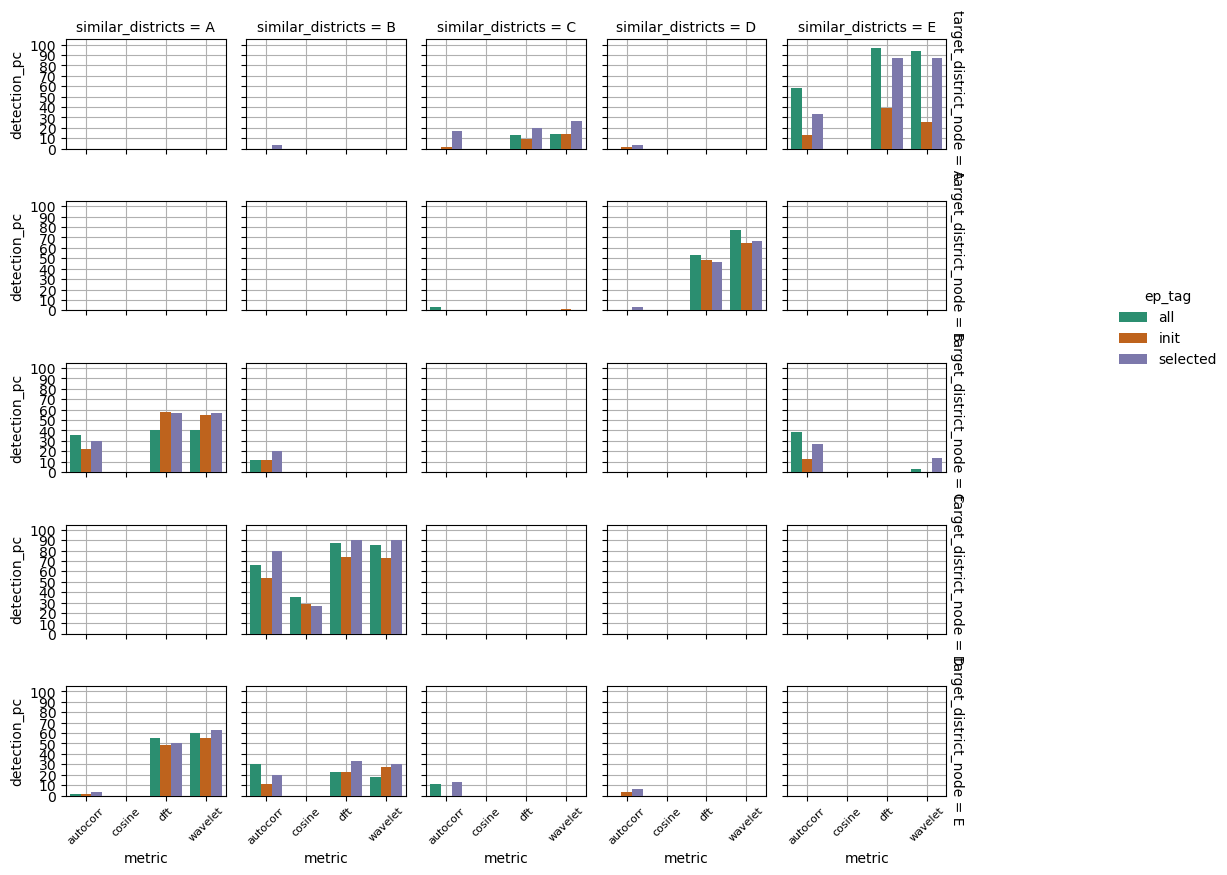

In [12]:
plot_similar_P2_hyper = processed_similar_hyper.groupby([
                                                                    'target_district_node', 'final_state', 'similar_districts', # geographical info
                                                                    'metric', 'ep_tag',                 # processing variable
                                                                ]
                                                              ).agg({
                                                                    'detection' : 'sum',
                                                                    'init_state' : 'count'
                                                                }).rename(columns = {'init_state' : 'count'}).reset_index()

plot_similar_P2_hyper['detection_pc'] = 100*plot_similar_P2_hyper['detection'] / plot_similar_P2_hyper['count']


plot_similar_P2_hyper = plot_similar_P2_hyper[(plot_similar_P2_hyper['final_state'].isin(['LH']))  
                                                             # & (plot_similar_P2_hyper['ep_tag'] == 'all')
                                                            # (plot_similar_P2_hyper['skip_tgt'] == True)
    ]


x_var = 'metric'
y_var = 'detection_pc'
hue_var = 'ep_tag'

col_var = 'similar_districts'
row_var = 'target_district_node'
row_order = ['A', 'B', 'C', 'D', 'E']

plot_grid(data = plot_similar_P2_hyper, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (0,105))

In [54]:
import pandas as pd
import itertools
import altair as alt

# Get all unique values
all_targets = row_order
all_similars = sorted(plot_similar_P2_hyper['similar_districts'].unique())
all_metrics = sorted(plot_similar_P2_hyper['metric'].unique())
all_ep_tags = sorted(plot_similar_P2_hyper['ep_tag'].unique())

# 1. Create full Cartesian product of all combinations
all_combos = pd.DataFrame(
    list(itertools.product(all_targets, all_similars, all_metrics, all_ep_tags)),
    columns=['target_district_node', 'similar_districts', 'metric', 'ep_tag']
)

# 2. Merge with your actual data
plot_filled = all_combos.merge(
    plot_similar_P2_hyper,
    on=['target_district_node', 'similar_districts', 'metric', 'ep_tag'],
    how='left'
)

plot_filled = plot_filled[(plot_filled['metric'].isin(['wavelet', 'dft'])) & (plot_filled['ep_tag'] != 'selected')]

# 3. Fill missing values with 0
for col in ['detection', 'count', 'detection_pc']:
    if col in plot_filled.columns:
        plot_filled[col] = plot_filled[col].fillna(0)

# 4. Mark self-comparison cases
plot_filled['is_self'] = plot_filled['target_district_node'] == plot_filled['similar_districts']

# 5. Ensure categorical ordering
plot_filled['target_district_node'] = pd.Categorical(plot_filled['target_district_node'], categories=all_targets, ordered=True)
plot_filled['similar_districts'] = pd.Categorical(plot_filled['similar_districts'], categories=all_similars, ordered=True)

# 6. Build Altair chart with conditional color
base = alt.Chart(plot_filled).mark_rect().encode(
    x=alt.X('metric:N', title=''),
    y=alt.Y('ep_tag:N', title=''),
    color=alt.Color(
        'detection_pc:Q',
        scale=alt.Scale(domain=[0, 100], scheme='viridis'),
        title='Detection %',
        legend=alt.Legend(
            labelFontSize=25,
            titleFontSize=30,
            symbolSize=5000
        )
    ),
    tooltip=[
        'target_district_node:N',
        'similar_districts:N',
        'metric:N',
        'ep_tag:N',
        alt.Tooltip('detection_pc:Q', format='.1f', title='Detection %')
    ]
).properties(width=80, height=80)

heatmap = (
    base
    .facet(
        row=alt.Row('target_district_node:N', sort=all_targets, title='Target District Node'),
        column=alt.Column('similar_districts:N', title='Similar District')
    )
    .configure_view(stroke=None)

    # Axis labels & titles
    .configure_axis(
        labelFontSize=25,
        titleFontSize=30
    )

    # Facet labels (row/column headers)
    .configure_header(
        labelFontSize=25,
        titleFontSize=30
    )

    # Legend text & title
    .configure_legend(
        labelFontSize=25,
        titleFontSize=30
    )

    # Chart title
    .configure_title(
        fontSize=16
    )
)


heatmap

alt.FacetChart(...)

,target_district_node,similar_districts,metric,ep_tag,final_state,detection,count,detection_pc,is_self
0,A,A,autocorr,all,NaN,0.0,0.0,0.0,True
1,A,A,autocorr,init,NaN,0.0,0.0,0.0,True
2,A,A,autocorr,selected,NaN,0.0,0.0,0.0,True
3,A,A,cosine,all,NaN,0.0,0.0,0.0,True
4,A,A,cosine,init,NaN,0.0,0.0,0.0,True
...,...,...,...,...,...,...,...,...,...
295,E,E,dft,init,NaN,0.0,0.0,0.0,True
296,E,E,dft,selected,NaN,0.0,0.0,0.0,True
297,E,E,wavelet,all,NaN,0.0,0.0,0.0,True
298,E,E,wavelet,init,NaN,0.0,0.0,0.0,True


In [327]:
import random

import altair as alt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import pandas as pd

alt.data_transformers.enable("vegafusion")

from collections import Counter

import glob
import wntr

import os

def check_district_node_coverage(full_node_list, district_node_dict, return_dict=False, verbose=True):
    """
    Checks that district node assignments:
    1. Do not overlap (no node appears in more than one district)
    2. Fully cover the nodes in the full network (no missing or extra nodes)

    Parameters:
    -----------
    full_node_list : list
        List of all junction names in the full network.

    district_node_dict : dict
        Dictionary with district names as keys and lists of junction names as values.

    return_dict : bool
        If True, Return results as dictionary.

    verbose : bool
        If True, prints details about overlaps and coverage issues.

    Returns:
    --------
    dict with keys:
        - 'overlapping_nodes': list of nodes found in multiple districts
        - 'missing_in_districts': nodes in full network but missing from districts
        - 'extra_in_districts': nodes in districts not present in full network
        - 'is_valid': True if all checks pass
    """
    # Flatten all district nodes
    all_district_nodes_flat = [node for nodes in district_node_dict.values() for node in nodes['nodes']]
    node_counts = Counter(all_district_nodes_flat)

    # Nodes in more than one district
    overlapping_nodes = [node for node, count in node_counts.items() if count > 1]

    # Set comparisons
    district_node_set = set(all_district_nodes_flat)
    full_node_set = set(full_node_list)

    missing_in_districts = full_node_set - district_node_set
    extra_in_districts = district_node_set - full_node_set

    # Verbose output
    if verbose:
        print("✅ No overlapping nodes." if not overlapping_nodes else "❌ Overlapping nodes found:")
        if overlapping_nodes:
            print(overlapping_nodes)

        print(
            "✅ All full network nodes are included." if not missing_in_districts else "❌ Missing nodes from districts:")
        if missing_in_districts:
            print(missing_in_districts)

        print(
            "✅ No extra nodes in districts." if not extra_in_districts else "⚠️ Extra nodes in districts not in full network:")
        if extra_in_districts:
            print(extra_in_districts)

    # Return results as dictionary
    return {
        'overlapping_nodes': overlapping_nodes,
        'missing_in_districts': list(missing_in_districts),
        'extra_in_districts': list(extra_in_districts),
        'is_valid': not (overlapping_nodes or missing_in_districts or extra_in_districts)
    } if return_dict else None
    
def load_network_and_districts(id_network, directory='networks\\original\\'):
    """
    Loads the full EPANET network and all associated district subnetwork files.

    Parameters:
    -----------
    id_network : str
        Base name of the full network file (without extension).

    directory : str
        Path to the folder containing the full network and district files.

    Returns:
    --------
    tuple:
        - wn_full : wntr WaterNetworkModel of the full network
        - district_nodes : dict {district_name: list of junction names}
    """
    # Pattern to find all district files
    pattern = os.path.join(directory, f'*{id_network}*District*.inp')
    district_files = glob.glob(pattern)

    # Load full network
    full_path = os.path.join(directory, f'{id_network}.inp')
    wn_full = wntr.network.WaterNetworkModel(full_path)
    all_nodes = wn_full.junction_name_list

    # Load districts
    district_nodes = {}
    for district in district_files:
        name = district.replace(os.path.join(directory, f'{id_network}_'), '').replace('.inp', '')
        wn = wntr.network.WaterNetworkModel(district)
        district_nodes[name] = {}
        district_nodes[name]['nodes'] = wn.junction_name_list
        district_nodes[name]['network'] = wn

        # Sanity check of district division
    results = check_district_node_coverage(full_node_list=all_nodes,
                                           district_node_dict=district_nodes,
                                           return_dict=True,
                                           verbose=True)
    if results['is_valid']:
        print("\nAll district assignments are valid.")

        return wn_full, district_nodes

    raise AttributeError('Please check the division of the network. Some nodes are overlapping/missing.')
    
wn, district_nodes = load_network_and_districts(id_network= 'Graeme',
                                                    directory='simulation/networks/original/')

✅ No overlapping nodes.
✅ All full network nodes are included.
✅ No extra nodes in districts.

All district assignments are valid.


In [411]:

class BuildingAssigner:
    def __init__(self, node_list, water_network, income_level='medium', density_level='medium', seed=23):
        """
        Initialize the building assigner using high-level urban characteristics.

        Parameters:
        -----------
        node_list : list of str
            List of node (junction) names in the district.

        water_network : wntr WaterNetworkModel
            The EPANET network model for the district.

        income_level : str
            One of 'low', 'medium', 'high' to influence standards.

        density_level : str
            One of 'low', 'medium', 'high' to influence building types.

        seed : int, optional
            Seed for reproducibility
        """
        self.node_list = node_list
        self.water_network = water_network
        self.standard_consumption = {1: 5, 2: 10, 3: 15, 4: 25, 5: 40}  # m³/month
        self.income = income_level
        self.density = density_level

        # Generate building templates + profile from high-level inputs
        houses, buildings_P, buildings_M, buildings_G, profile = generate_building_profiles(
            income_level=income_level,
            density_level=density_level,
            seed=seed
        )

        # Store results
        self.templates = {
            'houses': houses,
            'buildings_P': buildings_P,
            'buildings_M': buildings_M,
            'buildings_G': buildings_G
        }
        self.district_profile = profile
        self.data_buildings = None  # will be populated later

    def assign_buildings(self):
        """
        Assign building types to each node in the node list using the generated profile and templates.

        Returns:
        --------
        pd.DataFrame with columns: ['node_id', 'type', 'standard', 'consumption', 'units']
        """
        total_nodes = len(self.node_list)
        assignments = []
        node_index = 0

        # Shuffle nodes to randomize placement
        random.shuffle(self.node_list)

        for group in self.district_profile:
            template_name = group['template']
            ratio = group['ratio']
            config = self.templates[template_name]
            n_group = round(total_nodes * ratio)
            standards = list(config['standards'].items())
            building_type = config['type']

            for _ in range(n_group):
                if node_index >= total_nodes:
                    break
                node_id = self.node_list[node_index]
                standard = self._weighted_choice(standards)
                consumption = self.standard_consumption[standard]
                units = None

                # if building_type.lower() == 'apartments':
                units = random.randint(*config['units_range'])
                consumption *= units

                assignments.append({
                    'node_id': node_id,
                    'type': building_type,
                    'standard': standard,
                    'consumption': consumption,
                    'units': units
                })

                node_index += 1

        # Fill remaining nodes with default House type (mid-standard)
        while node_index < total_nodes:
            node_id = self.node_list[node_index]
            assignments.append({
                'node_id': node_id,
                'type': 'House',
                'standard': 2,
                'consumption': self.standard_consumption[2],
                'units': random.randint(2, 10)
            })
            node_index += 1

        # Create DataFrame
        results_df = pd.DataFrame(assignments)
        results_df['units'] = results_df['units'].fillna(1).astype(int)
        results_df['consumption_unit'] = results_df['consumption'] / results_df['units']
        results_df['income'] = self.income
        results_df['density'] = self.density

        self.data_buildings = results_df
        self.original_data_buildings = results_df.copy()

    def _weighted_choice(self, weighted_dict):
        options, weights = zip(*weighted_dict)
        return random.choices(options, weights=weights)[0]

    def describe_configuration(self):
        print("District Profile (template ratios):")
        for item in self.district_profile:
            print(f"  - {item['template']}: {item['ratio']:.3f}")

        print("\nStandards per template:")
        for name, template in self.templates.items():
            std = template['standards']
            print(f"  {name}: {std}")

    def edit_node(self, node_id, income_level='medium', density_level='medium', seed=None):
        """
        Edit a specific node's building assignment by reassigning it based on new income/density levels.

        Parameters:
        -----------
        node_id : str
            The node to be updated.

        income_level : str
            One of 'low', 'medium', 'high' to influence building standards.

        density_level : str
            One of 'low', 'medium', 'high' to influence building type.

        seed : int, optional
            Optional seed for deterministic assignment.
        """
        if self.data_buildings is None:
            raise ValueError("Buildings must be assigned first. Call assign_buildings() before editing nodes.")

        if node_id not in self.node_list:
            raise ValueError(f"Node '{node_id}' is not in the list of assigned nodes.")

        # Generate new templates/profile for just this node
        houses, buildings_P, buildings_M, buildings_G, profile = generate_building_profiles(
            income_level=income_level,
            density_level=density_level,
            seed=seed
        )

        templates = {
            'houses': houses,
            'buildings_P': buildings_P,
            'buildings_M': buildings_M,
            'buildings_G': buildings_G
        }

        # Randomly choose a template based on the new profile
        templates_with_weights = [(p['template'], p['ratio']) for p in profile]

        while True:
            selected_template = random.choices(
                [tpl for tpl, _ in templates_with_weights],
                weights=[w for _, w in templates_with_weights]
            )[0]
            
            # Avoid assign houses to medium/high populational densities
            if density_level != 'low' and selected_template != 'houses':
                break
            if density_level == 'low' and selected_template != 'buildings_G' and selected_template != 'buildings_M':
                break

        config = templates[selected_template]
        standard = self._weighted_choice(list(config['standards'].items()))
        consumption = self.standard_consumption[standard]
        building_type = config['type']
        # units = 1
        #
        # if building_type.lower() == 'apartments':
        units = random.randint(*config['units_range'])
        consumption *= units

        # Update the DataFrame
        new_row = {
            'node_id': node_id,
            'type': building_type,
            'standard': int(standard),
            'consumption': int(consumption),
            'units': int(units),
            'consumption_unit': consumption / units,
            'income': income_level,
            'density': density_level,
        }

        new_row_df = pd.DataFrame(data = [new_row], columns=self.data_buildings.columns)
        self.data_buildings.loc[self.data_buildings['node_id'] == node_id] = new_row_df.values

    def plot_assignments(self, show_edges=True, figsize=(12, 10)):
        """
        Plot the network with assigned buildings.

        Parameters:
        -----------
        show_edges : bool
            Whether to plot pipes between nodes.

        figsize : tuple
            Size of the figure.
        """
        # Map of markers by type
        type_marker = {'House': 'o', 'Apartments': 's'}
        standard_colors = {1: '#d73027', 2: '#fc8d59', 3: '#fee090', 4: '#91bfdb', 5: '#4575b4'}

        fig, ax = plt.subplots(figsize=figsize)

        # Optional: draw edges
        if show_edges:
            for link_name, link in self.water_network.links():
                start = self.water_network.get_node(link.start_node_name)
                end = self.water_network.get_node(link.end_node_name)
                x1, y1 = start.coordinates
                x2, y2 = end.coordinates
                ax.plot([x1, x2], [y1, y2], color='gray', linewidth=1, zorder=1)

        # Draw nodes with styling
        for _, row in self.data_buildings.iterrows():
            node = self.water_network.get_node(row['node_id'])
            x, y = node.coordinates
            marker = type_marker.get(row['type'], 'x')
            color = standard_colors.get(row['standard'], 'black')

            # Marker size: fixed for houses, scaled for apartments
            if row['type'] == 'Apartments' and pd.notna(row['units']):
                size = 40 + row['units'] * 0.5  # scalable size
            else:
                size = 80  # fixed size for houses

            ax.scatter(x, y, c=color, marker=marker, edgecolor='k', s=size, zorder=2)

        ax.set_title("Building Assignments in Water Network", fontsize=14)
        ax.set_xlabel("X Coordinate")
        ax.set_ylabel("Y Coordinate")
        ax.grid(True)

        # Legend
        house_patch = mlines.Line2D([], [], color='w', marker='o', label='House', markerfacecolor='gray',
                                    markeredgecolor='k', markersize=8)
        apt_patch = mlines.Line2D([], [], color='w', marker='s', label='Apartments (size ∝ units)',
                                  markerfacecolor='gray', markeredgecolor='k', markersize=8)
        std_patches = [mpatches.Patch(color=col, label=f'Standard {std}') for std, col in standard_colors.items()]
        ax.legend(handles=[house_patch, apt_patch] + std_patches, loc='best', fontsize=9)

        plt.tight_layout()
        plt.show()

    def plot_interactive_assignments(self, plot_size=(600, 400)):
        """
        Interactive Altair plot of the water network:
        - Nodes: colored, shaped, sized by attributes
        - Pipes: light gray lines
        - Filters: by type and standard
        """
        # 1. Node positions
        node_data = []
        for name, node in self.water_network.nodes():
            x, y = node.coordinates
            node_data.append({'node_id': name, 'x': x, 'y': y})
        nodes_df = pd.DataFrame(node_data)

        # 2. Pipe edges
        edge_data = []
        for link_name, link in self.water_network.links():
            n1 = self.water_network.get_node(link.start_node_name)
            n2 = self.water_network.get_node(link.end_node_name)
            x1, y1 = n1.coordinates
            x2, y2 = n2.coordinates
            edge_data.append({'x': x1, 'y': y1, 'x2': x2, 'y2': y2})
        edges_df = pd.DataFrame(edge_data)

        # 3. Merge assignments with positions
        shape_map = {'House': 'circle', 'Apartments': 'square'}
        color_map = {1: '#d73027', 2: '#fc8d59', 3: '#fee090', 4: '#91bfdb', 5: '#4575b4'}

        df = self.data_buildings.merge(nodes_df, on='node_id', how='left')
        df['shape'] = df['type'].map(shape_map)
        df['color'] = df['standard'].map(color_map)
        df['size'] = df.apply(
            lambda row: 40 + row['units'] * 0.5 if row['type'] == 'Apartments' and pd.notna(row['units']) else 25,
            axis=1
        )

        # 4. Create selections
        type_select = alt.selection_point(fields=['type'], bind='legend')
        std_select = alt.selection_point(fields=['standard'], bind='legend')

        # 5. Edge chart (always visible)
        edge_chart = alt.Chart(edges_df).mark_line(
            color='gray', strokeWidth=1, opacity=0.75
        ).encode(
            x='x:Q', y='y:Q', x2='x2:Q', y2='y2:Q'
        )

        # 6. Node chart (filtered)
        node_chart = alt.Chart(df).mark_point(
            filled=True, stroke='black', strokeWidth=0.75, fillOpacity=0.95
        ).encode(
            x='x:Q',
            y='y:Q',
            color=alt.Color('standard:N',
                            scale=alt.Scale(domain=list(color_map.keys()), range=list(color_map.values())),
                            legend=alt.Legend(title='Standard')),
            shape=alt.Shape('type:N',
                            scale=alt.Scale(domain=list(shape_map.keys()), range=list(shape_map.values())),
                            legend=alt.Legend(title='Building Type')),
            size=alt.Size('size:Q', legend=None),
            tooltip=[
                alt.Tooltip('node_id:N', title='Node'),
                alt.Tooltip('type:N', title='Type'),
                alt.Tooltip('standard:N', title='Standard'),
                alt.Tooltip('units:Q', title='Units')
            ]
        ).add_params(
            type_select, std_select
        ).transform_filter(
            type_select & std_select
        )

        # 7. Combine charts
        full_chart = (edge_chart + node_chart).properties(
            width=plot_size[0],
            height=plot_size[1],
            title='Building Assignments in Water Network',
        ).configure_view(
            stroke=None
        ).interactive()

        full_chart = (edge_chart + node_chart).interactive()

        return full_chart

    def plot_interactive_metric(self, node_metric_df, plot_size=(600, 400)):
        """
        Interactive Altair plot of the water network:
        - Nodes: colored by a continuous metric (e.g., detection_pc)
        - Pipes: light gray lines
        """
        import altair as alt
        import pandas as pd
    
        # 1. Node positions
        node_data = []
        for name, node in self.water_network.nodes():
            x, y = node.coordinates
            node_data.append({'node_id': name, 'x': x, 'y': y})
        nodes_df = pd.DataFrame(node_data)
    
        # 2. Pipe edges
        edge_data = []
        for link_name, link in self.water_network.links():
            n1 = self.water_network.get_node(link.start_node_name)
            n2 = self.water_network.get_node(link.end_node_name)
            x1, y1 = n1.coordinates
            x2, y2 = n2.coordinates
            edge_data.append({'x': x1, 'y': y1, 'x2': x2, 'y2': y2})
        edges_df = pd.DataFrame(edge_data)
    
        # 3. Merge metric values with positions
        # node_metric_df must have columns: ['node_id', 'metric_value']

        return nodes_df
        df = nodes_df.merge(node_metric_df, on='node_id', how='left')
    
        # 4. Edge chart
        edge_chart = alt.Chart(edges_df).mark_line(
            color='gray', strokeWidth=1, opacity=0.75
        ).encode(
            x='x:Q', y='y:Q', x2='x2:Q', y2='y2:Q'
        )
    
        # 5. Node chart (continuous color)
        node_chart = alt.Chart(df).mark_circle(stroke='black', strokeWidth=0.75).encode(
            x='x:Q',
            y='y:Q',
            color=alt.Color(
                'metric_value:Q',
                scale=alt.Scale(scheme='viridis'),
                title='Detection %'
            ),
            size=alt.value(50),
            tooltip=[
                alt.Tooltip('node_id:N', title='Node'),
                alt.Tooltip('metric_value:Q', format='.1f', title='Detection %')
            ]
        )
    
        # 6. Combine charts
        full_chart = (edge_chart + node_chart).properties(
            width=plot_size[0],
            height=plot_size[1],
            title='Water Network - Node Metric Visualization'
        ).configure_view(stroke=None).interactive()
    
        return full_chart


def combine_districts(district_nodes, init_assigner=True, plot_size=(600, 300)):
    """
    Assigns and plots interactive building distributions for all districts.

    Parameters:
    -----------
    district_nodes : dict
        A dictionary where keys are district names and values are dicts with:
            - 'nodes': list of node IDs
            - 'network': wntr WaterNetworkModel
    plot_size : tuple
        Width and height of each district plot.

    Returns:
    --------
    alt.Chart
        A combined interactive Altair chart for all districts.
    """
    charts = []

    for district_name, district_data in district_nodes.items():
        if init_assigner:
            assigner = BuildingAssigner(
                node_list=district_data['nodes'],
                water_network=district_data['network'],
                income_level=district_data['income'],
                density_level=district_data['density'],
            )

            assigner.assign_buildings()
            district_data['assignments'] = assigner

        chart = district_data['assignments'].plot_interactive_assignments(
            plot_size=plot_size,
        ).properties(title=f"District: {district_name}")

        charts.append(chart)

    # Overlay all district charts into one
    full_chart = alt.layer(*charts).properties(
        width=plot_size[0],
        height=plot_size[1],
        title='Building Assignments in All Districts',
    ).configure_view(
        stroke=None
    ).interactive()

    return full_chart

def generate_building_profiles(income_level='medium', density_level='medium', seed=23):
    """
    Generate building templates and district profiles with slight randomness, based on income and density levels.

    Parameters:
    -----------
    income_level : str
        One of 'low', 'medium', 'high'
    density_level : str
        One of 'low', 'medium', 'high'
    seed : int, optional
        Seed for reproducibility

    Returns:
    --------
    houses, buildings_P, buildings_M, buildings_G, district_profile
    """
    if seed is not None:
        random.seed(seed)

    # Base standards by income
    base_standards = {
        'low': {1: 0.40, 2: 0.40, 3: 0.175, 4: 0.025},
        'medium': {1: 0.10, 2: 0.30, 3: 0.50, 4: 0.10},
        'high': {3: 0.20, 4: 0.40, 5: 0.40}
    }

    def jitter_and_normalize(d, jitter=0.05):
        jittered = {k: max(0, v + random.uniform(-jitter, jitter)) for k, v in d.items()}
        total = sum(jittered.values())
        normalized = {k: round(v / total, 3) for k, v in jittered.items()}
        return normalized

    standards = jitter_and_normalize(base_standards[income_level])

    # Building templates
    houses = {
        'type': 'House',
        'standards': jitter_and_normalize({k: v for k, v in standards.items() if k <= 3 or income_level == 'high'}),
        'units_range': (3, 15)
    }

    buildings_P = {
        'type': 'Apartments',
        'standards': jitter_and_normalize({k: v for k, v in standards.items() if k >= 2}),
        'units_range': (15, 45)
    }

    buildings_M = {
        'type': 'Apartments',
        'standards': jitter_and_normalize({k: v for k, v in standards.items() if k >= 2}),
        'units_range': (50, 125)
    }

    buildings_G = {
        'type': 'Apartments',
        'standards': jitter_and_normalize({k: v for k, v in standards.items() if k >= 3}),
        'units_range': (125, 300)
    }

    # Base profile by density
    base_profile = {
        'low': {'houses': 0.80, 'buildings_P': 0.175, 'buildings_M': 0.025},
        'medium': {'houses': 0.30, 'buildings_P': 0.45, 'buildings_M': 0.25},
        'high': {'houses': 0.075, 'buildings_P': 0.275, 'buildings_M': 0.425, 'buildings_G': 0.225}
    }

    # Jitter and normalize ratios
    raw_ratios = {k: max(0, v + random.uniform(-0.025, 0.025)) for k, v in base_profile[density_level].items()}
    total = sum(raw_ratios.values())
    profile = [{'template': k, 'ratio': round(v / total, 3)} for k, v in raw_ratios.items()]

    return houses, buildings_P, buildings_M, buildings_G, profile

income_density_mapping = 'HL_LL_LL_LL_LH'
parts = income_density_mapping.split('_')
level_map = {'H': 'high', 'M': 'medium', 'L': 'low'}  # make sure level_map exists
income_density_mapping = [(level_map[p[0]], level_map[p[1]]) for p in parts]

# Assign income and density attributes to each district using predefined mapping
for i, district in enumerate(district_nodes.values()):
    district['income'] = income_density_mapping[i][0]
    district['density'] = income_density_mapping[i][1]

# Create a visual chart of combined districts (optional visualization)
chart = combine_districts(
    district_nodes=district_nodes,
    plot_size=(600, 400)
)
chart

alt.LayerChart(...)

In [397]:
def combine_districts_metric(district_nodes, node_metric_df_dict, init_assigner=True, plot_size=(600, 300)):
    """
    Assigns and plots interactive metric-colored node maps for all districts using
    the new `plot_interactive_metric` method.

    Parameters:
    -----------
    district_nodes : dict
        Dictionary where keys are district names and values are dicts containing:
            - 'nodes': list of node IDs
            - 'network': wntr WaterNetworkModel
            - other info
    node_metric_df_dict : dict
        Dictionary keyed by district names with pd.DataFrame values having columns:
        ['node_id', 'metric_value'] for coloring nodes.
    init_assigner : bool
        Whether to initialize BuildingAssigner for each district.
    plot_size : tuple
        Size of each district plot.

    Returns:
    --------
    alt.Chart
        An Altair layered chart with all districts overlaid.
    """

    charts = []

    for district_name, district_data in district_nodes.items():
        if init_assigner:
            assigner = BuildingAssigner(
                node_list=district_data['nodes'],
                water_network=district_data['network'],
                income_level=district_data['income'],
                density_level=district_data['density'],
            )
            assigner.assign_buildings()
            district_data['assignments'] = assigner

        # Extract metric DataFrame for this district
        node_metric_df = node_metric_df_dict.get(district_name, pd.DataFrame(columns=['node_id', 'metric_value']))

        # Use the new plotting method with the metric DataFrame
        chart = district_data['assignments'].plot_interactive_metric(
            node_metric_df=node_metric_df,
            plot_size=plot_size,
        ).properties(title=f"District: {district_name}")

        charts.append(chart)

    # Overlay all district charts into one Altair layer
    full_chart = alt.layer(*charts).properties(
        width=plot_size[0],
        height=plot_size[1],
        title='Node Metric Visualization in All Districts',
    ).configure_view(
        stroke=None
    ).interactive()

    return full_chart

node_metric_df_dict = {}


# Create a visual chart of combined districts (optional visualization)
chart = combine_districts_metric(district_nodes = district_nodes,
                                 node_metric_df_dict = node_metric_df_dict,
                                 init_assigner=True, plot_size=(600, 300))
chart

TypeError: Objects with 'config' attribute cannot be used within LayerChart. Consider defining the config attribute in the LayerChart object instead.

In [413]:
charts = []

for district_name, district_data in district_nodes.items():
    assigner = BuildingAssigner(
        node_list=district_data['nodes'],
        water_network=district_data['network'],
        income_level=district_data['income'],
        density_level=district_data['density'],
    )

    assigner.assign_buildings()
    district_data['assignments'] = assigner

chart = district_data['assignments'].plot_interactive_metric(
    node_metric_df = plot_filled,
    plot_size=(600,300),
).properties(title=f"District: {district_name}")

charts.append(chart)

AttributeError: 'DataFrame' object has no attribute 'properties'

In [415]:
chart

alt.LayerChart(...)

In [103]:
df_detect_income = pd.read_csv(f'results/income_base/traceback/INCOMESIMPLE/compiled_detection.csv')

processed_detect_income = df_detect_income.copy()
processed_detect_income[['window', 'step_size', 'interval']] = processed_detect_income['setup'].str.split('_', expand = True).astype(int)

processed_detect_income['interval'] = (processed_detect_income['interval'] / 3600).astype(int)
processed_detect_income['step_ratio'] = round(processed_detect_income['step_size']  / processed_detect_income['window'], 3)


processed_detect_income['init_state'] = processed_detect_income['state_map'].str[:2]
processed_detect_income['final_state'] = processed_detect_income['state_map'].str[3:5]

processed_detect_income.drop(columns = ['setup', 'exp_id', 'state_map'], inplace = True)

processed_detect_income.head()

,period,drift_type,wrong_%,correct_%,method,skip_tgt,epochs_tgt,period_tgt,detection,window,step_size,interval,step_ratio,init_state,final_state
0,all_periods,first_vs_later,33.33,66.67,max cosine,True,selected_epochs,Overlapped,1,12,2,2,0.167,LL,HL
1,all_periods,rolling,0.00,100.00,max cosine,True,selected_epochs,Overlapped,1,12,2,2,0.167,LL,HL
2,first_4_months,first_vs_later,0.00,100.00,max cosine,True,selected_epochs,Overlapped,1,12,2,2,0.167,LL,HL
3,first_4_months,rolling,33.33,66.67,max cosine,True,selected_epochs,Overlapped,1,12,2,2,0.167,LL,HL
4,first_year,first_vs_later,0.00,100.00,max cosine,True,selected_epochs,Overlapped,1,12,2,2,0.167,LL,HL


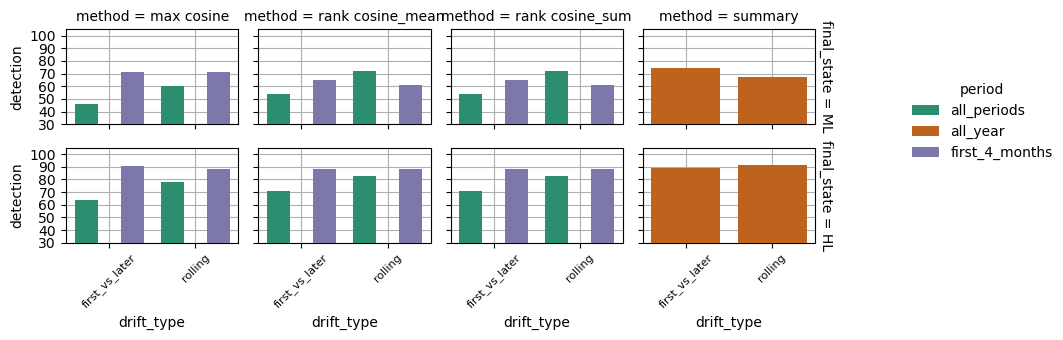

In [105]:
plot_detect_income = processed_detect_income.groupby(['final_state', 'epochs_tgt', 'skip_tgt',  # epocas utilizadas
                                                                 'period', 'period_tgt',    # meses (labels) considerados
                                                                 'drift_type', 'method']  # tipo análise
                                                              ).agg({
                                                                'correct_%' : 'sum',
                                                                'period' : 'count'
                                                            }).rename(columns = {'period' : 'count'}).reset_index()

plot_detect_income['detection'] = plot_detect_income['correct_%'] / plot_detect_income['count']

plot_detect_income = plot_detect_income[(plot_detect_income['period_tgt'] == 'Targeted') & 
                                        (plot_detect_income['epochs_tgt'] == 'all') & 
                                        (plot_detect_income['skip_tgt'] == True)]

x_var = 'drift_type'
y_var = 'detection'
hue_var = 'period'

col_var = 'method'
row_var = 'final_state'
row_order = ['ML', 'HL']

plot_grid(data = plot_detect_income, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (30,105))

In [67]:
import glob
import os
import pandas as pd

# Step 1: Get all matching directories
base_path = 'results/income_base/traceback/HYPER_INCOME'
# base_path = 'results/density_base/traceback/HYPER'
pattern = os.path.join(base_path, '*2_*/')
directories = [d for d in glob.glob(pattern) if os.path.isdir(d)]

# Step 2: Count files in each directory

aux_det = []
aux_sim = []

for dir_path in directories:
    files = [f for f in glob.glob(os.path.join(dir_path, '*')) if os.path.isfile(f)]
    det = pd.read_csv(f'{dir_path}/compiled_detection.csv')
    sim = pd.read_csv(f'{dir_path}/compiled_similarity.csv')

    aux_det.append(det)
    aux_sim.append(sim)

df_detect_hyper = pd.concat(aux_det, ignore_index=True)
df_detect_hyper.head()

,state_map,period,drift_type,wrong_%,correct_%,setup,method,skip_tgt,epochs_tgt,period_tgt,detection,exp_id
0,LL_HL__HL_LL_LL_LL_ML,all_periods,first_vs_later,33.33,66.67,12_2_14400_40_0.4,max cosine,True,init,Overlapped,1,HYPER_INCOME
1,LL_HL__HL_LL_LL_LL_ML,all_periods,rolling,40.00,60.00,12_2_14400_40_0.4,max cosine,True,init,Overlapped,1,HYPER_INCOME
2,LL_HL__HL_LL_LL_LL_ML,first_4_months,first_vs_later,0.00,100.00,12_2_14400_40_0.4,max cosine,True,init,Overlapped,1,HYPER_INCOME
3,LL_HL__HL_LL_LL_LL_ML,first_4_months,rolling,33.33,66.67,12_2_14400_40_0.4,max cosine,True,init,Overlapped,1,HYPER_INCOME
4,LL_HL__HL_LL_LL_LL_ML,first_year,first_vs_later,0.00,100.00,12_2_14400_40_0.4,max cosine,True,init,Overlapped,1,HYPER_INCOME


In [69]:
processed_detect_hyper = df_detect_hyper.copy()
processed_detect_hyper[['window', 'step_size', 'interval', 'lstm', 'info']] = processed_detect_hyper['setup'].str.split('_', expand = True).astype(float)

for c in ['window', 'step_size', 'interval', 'lstm']:
    processed_detect_hyper[c] = processed_detect_hyper[c].astype(int)
    
processed_detect_hyper['interval'] = (processed_detect_hyper['interval'] / 3600).astype(int)
processed_detect_hyper['step_ratio'] = round(processed_detect_hyper['step_size']  / processed_detect_hyper['window'], 3)


processed_detect_hyper['init_state'] = processed_detect_hyper['state_map'].str[:2]
processed_detect_hyper['final_state'] = processed_detect_hyper['state_map'].str[3:5]

processed_detect_hyper.drop(columns = ['setup', 'exp_id', 'state_map'], inplace = True)

for c in ['window', 'step_size', 'interval', 'lstm', 'info']:
    print(c, processed_detect_hyper[c].unique().tolist())
    
processed_detect_hyper.head()

window [12, 48, 84]
step_size [2]
interval [4]
lstm [40, 10, 30, 60]
info [0.4, 0.2, 0.05, 0.1]


,period,drift_type,wrong_%,correct_%,method,skip_tgt,epochs_tgt,period_tgt,detection,window,step_size,interval,lstm,info,step_ratio,init_state,final_state
0,all_periods,first_vs_later,33.33,66.67,max cosine,True,init,Overlapped,1,12,2,4,40,0.4,0.167,LL,HL
1,all_periods,rolling,40.00,60.00,max cosine,True,init,Overlapped,1,12,2,4,40,0.4,0.167,LL,HL
2,first_4_months,first_vs_later,0.00,100.00,max cosine,True,init,Overlapped,1,12,2,4,40,0.4,0.167,LL,HL
3,first_4_months,rolling,33.33,66.67,max cosine,True,init,Overlapped,1,12,2,4,40,0.4,0.167,LL,HL
4,first_year,first_vs_later,0.00,100.00,max cosine,True,init,Overlapped,1,12,2,4,40,0.4,0.167,LL,HL


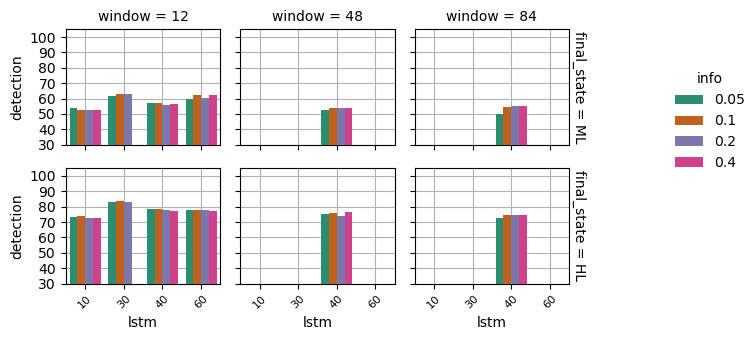

In [77]:
plot_detect_hyper = processed_detect_hyper.groupby(['final_state', 'window', 'lstm', 'info'] 
                                                              ).agg({
                                                                'correct_%' : 'sum',
                                                                'period' : 'count'
                                                            }).rename(columns = {'period' : 'count'}).reset_index()

plot_detect_hyper['detection'] = plot_detect_hyper['correct_%'] / plot_detect_hyper['count']

x_var = 'lstm'
y_var = 'detection'
hue_var = 'info'

col_var = 'window'
row_var = 'final_state'

row_order = ['ML', 'HL']

plot_grid(data = plot_detect_hyper, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (30,105))

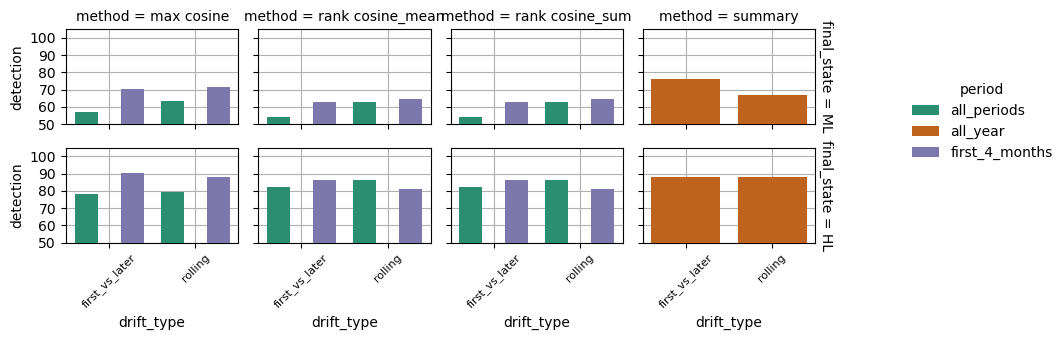

In [113]:
processed_detect_hyper_selected = processed_detect_hyper[(processed_detect_hyper['lstm'] == 30) & (processed_detect_hyper['info'] == 0.1)]

processed_detect_hyper_selected = processed_detect_hyper_selected[(processed_detect_hyper_selected['period_tgt'] == 'Targeted') & 
                                                            (processed_detect_hyper_selected['epochs_tgt'] == 'all') & 
                                                            (processed_detect_hyper_selected['skip_tgt'] == True)]


plot_detect_hyper_selected = processed_detect_hyper_selected.groupby(['final_state', 'epochs_tgt', 'skip_tgt',  # epocas utilizadas
                                                                 'period', 'period_tgt',    # meses (labels) considerados
                                                                 'drift_type', 'method']  # tipo análise
                                                              ).agg({
                                                                'correct_%' : 'sum',
                                                                'period' : 'count'
                                                            }).rename(columns = {'period' : 'count'}).reset_index()

plot_detect_hyper_selected['detection'] = plot_detect_hyper_selected['correct_%'] / plot_detect_hyper_selected['count']


x_var = 'drift_type'
y_var = 'detection'
hue_var = 'period'

col_var = 'method'
row_var = 'final_state'
row_order = ['ML', 'HL']

plot_grid(data = plot_detect_hyper_selected, x_var = x_var, y_var = y_var, hue_var = hue_var, col_var = col_var, row_var = row_var,
             col_order = None, row_order = row_order, ylims = (50,105))

In [115]:
plot_detect_hyper_selected[plot_detect_hyper_selected['final_state'] == 'ML'].sort_values(by = 'detection', ascending = False).head(5)

,final_state,epochs_tgt,skip_tgt,period,period_tgt,drift_type,method,correct_%,count,detection
20,ML,all,True,all_year,Targeted,first_vs_later,summary,1300.01,17,76.471176
25,ML,all,True,first_4_months,Targeted,rolling,max cosine,1216.66,17,71.568235
22,ML,all,True,first_4_months,Targeted,first_vs_later,max cosine,1200.01,17,70.588824
21,ML,all,True,all_year,Targeted,rolling,summary,1133.33,17,66.666471
26,ML,all,True,first_4_months,Targeted,rolling,rank cosine_mean,1100.00,17,64.705882


In [109]:
plot_detect_income[plot_detect_income['final_state'] == 'ML'].sort_values(by = 'detection', ascending = False).head(5)

,final_state,epochs_tgt,skip_tgt,period,period_tgt,drift_type,method,correct_%,count,detection
214,ML,all,True,all_year,Targeted,first_vs_later,summary,3800.05,51,74.510784
210,ML,all,True,all_periods,Targeted,rolling,rank cosine_mean,3683.37,51,72.222941
211,ML,all,True,all_periods,Targeted,rolling,rank cosine_sum,3683.37,51,72.222941
225,ML,all,True,first_4_months,Targeted,rolling,max cosine,3650.01,51,71.568824
222,ML,all,True,first_4_months,Targeted,first_vs_later,max cosine,3633.33,51,71.241765
